# Regression Tree Implementation

In this module, we implement a Regression Tree using the DecisionTreeRegressor from scikit learn. Regression trees are non parametric models that recursively partition the feature space into regions that minimize prediction error. This allows them to capture nonlinear relationships and feature interactions that linear models cannot represent.

The implementation follows a structured machine learning workflow consisting of data inspection, preprocessing, model training, hyperparameter tuning, and performance evaluation.

In [1]:
import os, sys
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath("../../../src"))

from rice_ml.supervised_learning.regression_trees import (
    RegressionTree,
    RegressionTreeConfig,
    tune_max_depth,
)

**Phase 1: Data Inspection and Preparation**

The dataset used for this experiment is the Boston Housing dataset, which contains housing related features such as crime rate, number of rooms, property tax, and accessibility to highways. The target variable is the median value of owner occupied homes.

An initial inspection of the dataset shows that a small number of missing values are present in the rm feature. Since decision tree models cannot handle missing values directly, preprocessing is required prior to model training.

To avoid modifying the shared dataset used across the group project, missing values are handled within the notebook using median imputation. Median imputation preserves all observations while remaining robust to outliers.

In [2]:
df = pd.read_csv("../../../datasets/BostonHousing.csv")
target_col = "medv"

df.shape, df.columns

((506, 14),
 Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
        'ptratio', 'b', 'lstat', 'medv'],
       dtype='object'))

**Phase 2: Handling Missing Values**

Missing values are replaced using median imputation applied independently to each feature. This ensures that the dataset contains no NaN values while minimizing distortion of the original feature distributions.

This preprocessing step enables successful model training without altering the underlying dataset or introducing additional modeling assumptions.

In [3]:
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]

rm    5
dtype: int64

In [4]:
from sklearn.impute import SimpleImputer

X_raw = df.drop(columns=[target_col])
y = df[target_col]

imp = SimpleImputer(strategy="median")
X = pd.DataFrame(imp.fit_transform(X_raw), columns=X_raw.columns)

**Phase 3: Model Training and Hyperparameter Tuning**

The dataset is split into training and testing subsets using a 67 percent 33 percent split. A regression tree is then trained on the training data.

One of the most important hyperparameters for regression trees is maximum depth, which controls model complexity. Shallow trees may underfit the data, while deeper trees may overfit by memorizing noise.

To identify an appropriate depth, the model is trained using multiple values of maximum depth, and the Mean Squared Error is evaluated on the test set for each depth.


In [5]:
rt = RegressionTree(RegressionTreeConfig(test_size=0.33, random_state=42))
X_train, X_test, y_train, y_test = rt.split(X, y)

tuning = tune_max_depth(
    X_train,
    y_train,
    X_test,
    y_test,
    depths=range(1, 21),
    random_state=42,
)

tuning.head()

,max_depth,mse,mae,r2
0,6,15.055707,2.643620,0.801057
1,4,15.399930,2.781704,0.796509
2,5,15.449033,2.681769,0.795860
3,7,16.689563,2.725903,0.779468
4,9,16.893512,2.720904,0.776773


Note: Max Depth vs Mean Squared Error

This plot illustrates how model performance changes as tree depth increases. The error decreases rapidly for shallow depths as the model gains expressive power, then stabilizes and begins to fluctuate as overfitting occurs.

The optimal tree depth is selected as the depth that minimizes test set Mean Squared Error.

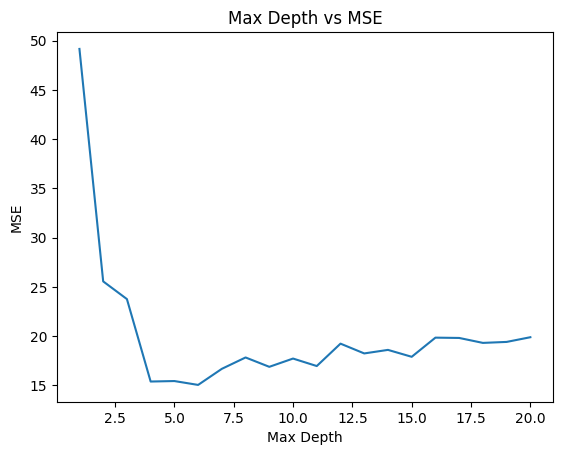

In [6]:
plt.figure()
plot_df = tuning.sort_values("max_depth")
plt.plot(plot_df["max_depth"], plot_df["mse"])
plt.xlabel("Max Depth")
plt.ylabel("MSE")
plt.title("Max Depth vs MSE")
plt.show()

In [7]:
best_depth = int(tuning.iloc[0]["max_depth"])
best_depth

6

Phase 4: Final Model Training and Evaluation

Using the optimal tree depth, the regression tree is retrained on the training data and evaluated on the test set.

The final model achieves strong predictive performance, demonstrating that regression trees can effectively model nonlinear relationships in structured tabular data and the values are actually pretty strong without any further tuning ^^

In [8]:
rt = RegressionTree(RegressionTreeConfig(test_size=0.33, random_state=42, max_depth=best_depth))
rt.fit(X_train, y_train)
rt.evaluate(X_test, y_test)

{'mse': 15.055707201689193, 'mae': 2.643619755782524, 'r2': 0.8010570302523988}

Performance Metrics

The following evaluation metrics are used:

Mean Squared Error measures average squared prediction error and penalizes large mistakes.
Mean Absolute Error measures average absolute deviation and provides an intuitive measure of prediction accuracy.
R squared measures the proportion of variance in housing prices explained by the model.

An R squared value close to 0.80 indicates that the model explains a large portion of variability in housing prices using a single regression tree. <br>

Also cause:<br>
   if error ↓ and r² ↑ : <br>
       ship it

Feeling like a couple more graphs for this one which are actually useful, so lets look at them. <br>
<br>
As to why: 
   me: trains model <br>
   model: performs well <br>
   me: suspicious <br>
<br>
      (ಠ_ಠ)

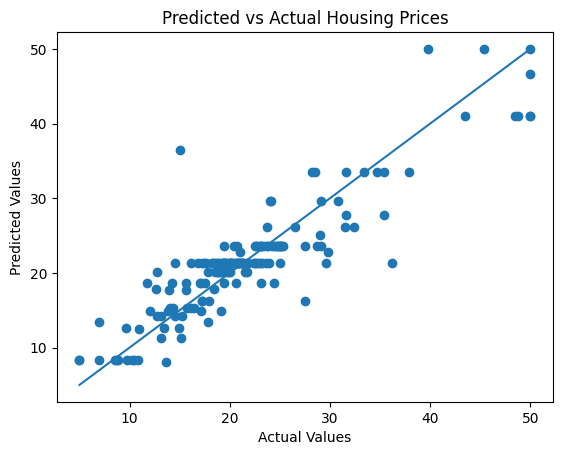

In [9]:
y_pred = rt.predict(X_test)

plt.figure()
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Actual Housing Prices")
plt.show()


To further evaluate the effectiveness of the regression tree, an actual versus predicted values plot is included. Each point represents a test sample, with the diagonal line indicating perfect predictions.

Most points cluster closely around the diagonal, which suggests that the model is generally capturing the underlying relationship between the input features and housing prices. Deviations from the line indicate prediction error, which is expected given the complexity and variability of real world housing data.

This visualization provides an intuitive confirmation of the quantitative metrics reported earlier. While MSE and MAE summarize error numerically, this plot shows how predictions behave across the full range of values rather than only in aggregate.

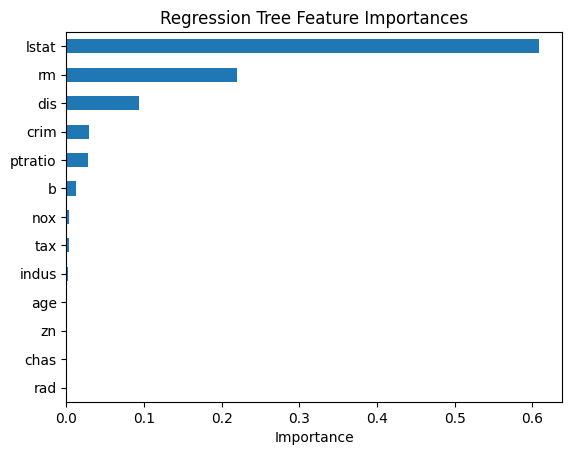

In [10]:
importance = pd.Series(
    rt.model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure()
importance.plot(kind="barh")
plt.xlabel("Importance")
plt.title("Regression Tree Feature Importances")
plt.gca().invert_yaxis()
plt.show()

**Feature Importance Interpretation**

The feature importance plot highlights which variables the regression tree relied on most heavily when making predictions. Features related to housing size and socioeconomic conditions dominate, which aligns well with domain intuition for housing price estimation.

This is one of the advantages of regression trees. In addition to strong predictive performance, they offer a level of interpretability by exposing which features drive decisions. Rather than treating the model as a black box, this allows us to reason about why certain predictions are made.